# ESMCBA: ESM-Cambrian Binding Affinity Prediction

## 📚 Project Overview

**ESMCBA** (ESM-Cambrian Binding Affinity) is a deep learning framework for predicting peptide–MHC (pMHC) binding affinity using protein language models.

### Key Features
- **Continued Pre-training**: Domain-specific pre-training of ESM Cambrian models on HLA-associated peptides
- **Binding Affinity Prediction**: Quantitative IC₅₀ prediction for peptide-MHC-I interactions
- **Allele Coverage**: Improved predictions especially for underrepresented HLA alleles
- **Multiple Input Formats**: Supports epitope-only or epitope+HLA concatenated sequences

### Resources
- **Code Repository**: [github.com/sermare/ESMCBA](https://github.com/sermare/ESMCBA)
- **Pre-trained Models**: [huggingface.co/smares/ESMCBA](https://huggingface.co/smares/ESMCBA)
- **Publication**: Published July 15, 2024
- **Authors**: Sergio E. Mares, Ariel Espinoza Weinberger, Nilah M. Ioannidis

---

## 📋 Technical Specifications

| Component | Details |
|-----------|----------|
| **Base Model** | ESM Cambrian (300M parameters) |
| **Python Version** | 3.10+ |
| **PyTorch** | GPU-enabled installation recommended |
| **Transformers** | Installed from PyPI |
| **ESM** | Installed from PyPI |
| **Training Data** | IEDB IC₅₀ tables, HLA sequences, Apollo test sets |
| **Output Format** | Embeddings, binding affinity predictions, visualizations |

---


## 🔧 Section 1: Environment Setup

We recommend using a clean **Python 3.10** environment (for example, created with `conda` or `python -m venv`) and installing the usual scientific Python stack (PyTorch, transformers, ESM, NumPy, pandas, Matplotlib, etc.).

The only strict compatibility requirement for this tutorial is that **`huggingface-hub` must be kept below version 1.0** (`huggingface-hub<1.0`) so that ESMCBA and the underlying models load correctly.

If you're running on a managed environment (such as Google Colab), make sure the runtime is using Python 3.10 if possible, then run the installation cells below once.


In [1]:
# Install core PyTorch and Transformers ecosystem
!pip install torch
!pip install transformers
!pip install esm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 79.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 91.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.4/139.4 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.7/302.7 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 92.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 129.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 85.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 113.5

### 1.2 Install Scientific Computing Libraries

In [2]:
# Install scientific computing and visualization libraries
!pip install biopython umap-learn scikit-learn seaborn pandas matplotlib


### 1.3 Install Hugging Face Hub Tools

These tools are essential for downloading pre-trained model checkpoints from Hugging Face.

In [3]:
# Install Hugging Face Hub utilities
!pip install "huggingface-hub<1.0"

# Optional: Install hf_transfer for faster large file downloads
!pip install hf_transfer


### 2.3 Verify Installation

Let's verify that all critical packages are installed and can be imported.

In [4]:
# Verify critical imports
import sys
import numpy as np
import pandas as pd
import torch
import transformers
from huggingface_hub import hf_hub_download

print("\n=== Environment Verification ===")
print(f"Python version: {sys.version.split()[0]}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"Transformers version: {transformers.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print("\n✅ All packages imported successfully!")


=== Environment Verification ===
Python version: 3.12.12
NumPy version: 2.0.2
Pandas version: 2.2.2
PyTorch version: 2.8.0+cu126
Transformers version: 4.48.1
CUDA available: True
CUDA version: 12.6
GPU: Tesla T4

✅ All packages imported successfully!


---

## 📥 Section 2: Download ESMCBA Repository and Models

### 2.1 Clone the ESMCBA Repository

In [5]:
# Clone the ESMCBA repository
!git clone https://github.com/sermare/ESMCBA.git

print("\n✅ Repository cloned successfully")

Cloning into 'ESMCBA'...
remote: Enumerating objects: 1082, done.
remote: Counting objects: 100% (143/143), done.
remote: Compressing objects: 100% (115/115), done.
remote: Total 1082 (delta 48), reused 108 (delta 27), pack-reused 939 (from 2)
Receiving objects: 100% (1082/1082), 356.04 MiB | 25.33 MiB/s, done.
Resolving deltas: 100% (454/454), done.

✅ Repository cloned successfully


### 2.2 Download Pre-trained Model Checkpoint

This downloads a specific fine-tuned model for HLA-A*02:01 allele from Hugging Face.

**Model Details**:
- **Base**: ESM Cambrian with epitope encoding
- **Pre-training**: Masked language modeling on HLA-associated peptides (0.8 masking, 30 epochs)
- **Fine-tuning**: IC₅₀ binding affinity prediction for HLA-A*02:01
- **Loss Function**: Huber loss (robust to outliers)
- **Input Format**: Epitope sequences only

In [6]:
# Download pre-trained model checkpoint from Hugging Face
!huggingface-cli download smares/ESMCBA \
  "ESMCBA_epitope_0.8_30_ESMMASK_epitope_FT_5_0.001_1e-06_AUG_6_HLAA0201_2_0.001_1e-06__2_A0201_Hubber_A0201_final.pth" \
  --repo-type model \
  --local-dir ./models

print("\n✅ Model checkpoint downloaded successfully")

⚠️  Warning: 'huggingface-cli download' is deprecated. Use 'hf download' instead.
ESMCBA_epitope_0.8_30_ESMMASK_epitope_FT(…): 100% 666M/666M [00:04<00:00, 156MB/s]
Download complete. Moving file to models/ESMCBA_epitope_0.8_30_ESMMASK_epitope_FT_5_0.001_1e-06_AUG_6_HLAA0201_2_0.001_1e-06__2_A0201_Hubber_A0201_final.pth
models/ESMCBA_epitope_0.8_30_ESMMASK_epitope_FT_5_0.001_1e-06_AUG_6_HLAA0201_2_0.001_1e-06__2_A0201_Hubber_A0201_final.pth

✅ Model checkpoint downloaded successfully


### 2.3 Create Output Directory

In [7]:
# Create output directory for results
!mkdir -p ./outputs

print("✅ Output directory created")

✅ Output directory created


---

## 🧬 Section 3: Generate Peptide Embeddings

### 3.1 Understanding the Embedding Generation Process

The embedding generation script:
1. Loads the pre-trained ESMCBA model
2. Processes input peptide sequences
3. Generates contextualized embeddings for each peptide
4. Optionally predicts binding affinity (if using a fine-tuned model)

#### 3.1.1 Why use the *last hidden layer*?

Internally, ESMCBA uses the **final hidden layer** of the ESM backbone (or a small stack of the last layers) as the peptide representation. Earlier transformer layers tend to capture more **local / low-level** patterns (e.g., short-range amino-acid context), while the last layers encode more **global, task-relevant features** that are useful for binding prediction:

- The last layer sees the entire sequence with full self-attention and aggregates long-range dependencies.
- During fine-tuning on binding data, the gradients primarily update the top layers, so the last layer becomes the most specialized for **pMHC binding**.
- Using the last hidden layer gives a **compact, fixed-size embedding** for each position that can be pooled (e.g., attention pooling or mean pooling) into a single peptide vector used by the regression head.

This is why the embedding-generation script exports features derived from the **last hidden layer**: these are the most informative representations to reuse for downstream analysis, visualization, or secondary models.


### 3.2 Parameter Explanation

| Parameter | Description |
|-----------|-------------|
| `--model_path` | Path to the pre-trained model checkpoint (.pth file) |
| `--name` | Experiment name for output files |
| `--hla` | HLA allele identifier (e.g., B5101, A0201) |
| `--encoding` | Input format: 'epitope' (peptide only) or 'epitope_hla' (concatenated) |
| `--output_dir` | Directory to save embeddings and predictions |
| `--peptides` | Space-separated list of peptide sequences to analyze |

### 3.3 Navigate to ESMCBA Directory

In [8]:
# Navigate to the ESMCBA code directory
%cd ESMCBA/ESMCBA

# Verify we're in the correct directory
!pwd
!ls -la

/content/ESMCBA/ESMCBA
/content/ESMCBA/ESMCBA
total 112
drwxr-xr-x 4 root root  4096 Nov 13 01:32 .
drwxr-xr-x 8 root root  4096 Nov 13 01:32 ..
-rw-r--r-- 1 root root  8194 Nov 13 01:32 embeddings_generation.py
-rw-r--r-- 1 root root  5070 Nov 13 01:32 ESMC_embeddings.py
-rw-r--r-- 1 root root  5477 Nov 13 01:32 evaluation_IEDB_qual.py
-rw-r--r-- 1 root root  3991 Nov 13 01:32 forward_pass_unsupervised.py
-rw-r--r-- 1 root root  4018 Nov 13 01:32 graph_utils.py
-rw-r--r-- 1 root root  6538 Nov 13 01:32 HLA_full_sequences_UMAP.py
-rw-r--r-- 1 root root   777 Nov 13 01:32 imports.py
-rw-r--r-- 1 root root     0 Nov 13 01:32 __init__.py
-rw-r--r-- 1 root root  3969 Nov 13 01:32 make_ESMCBA_models.py
-rw-r--r-- 1 root root  5457 Nov 13 01:32 model_evaluation.py
drwxr-xr-x 4 root root  4096 Nov 13 01:32 models
-rw-r--r-- 1 root root  8176 Nov 13 01:32 other_utils.py
drwxr-xr-x 2 root root  4096 Nov 13 01:32 __pycache__
-rwxr-xr-x 1 root root 26516 Nov 13 01:32 run_RFDiffusionMHC_epitope.py

## 3.3 COVID-19 as a test case: generate candidate epitopes

To make the tutorial concrete, we will use **SARS-CoV-2 (COVID-19)** as a test case.

- We download the **reference proteome** from UniProt (proteome ID `UP000464024`).
- For each viral protein, we generate all **overlapping 8–11mer peptides**. These are typical class I epitope lengths for HLA-A*02:01.
- We then pass a subset of these peptides (e.g., 10 000) into **ESMCBA (A0201 model)** to obtain:
  - Last-hidden-layer–based embeddings
  - Predicted binding affinity values (IC₅₀-like)

This gives us a *computational screen* of potential HLA-A*02:01 binders across the full COVID-19 proteome. The next cells:

1. Download the proteome FASTA file.
2. Slice it into 8–11mer peptides and save them in a TSV.
3. Create a simple text file with one peptide per line for the `--peptides` argument.


In [9]:
!wget -O sars_cov2_proteome.fasta \
  "https://rest.uniprot.org/uniprotkb/stream?compressed=false&format=fasta&query=proteome:UP000464024"

# Quick sanity check
!head -n 20 sars_cov2_proteome.fasta


--2025-11-13 01:32:32--  https://rest.uniprot.org/uniprotkb/stream?compressed=false&format=fasta&query=proteome:UP000464024
Resolving rest.uniprot.org (rest.uniprot.org)... 193.62.193.81
Connecting to rest.uniprot.org (rest.uniprot.org)|193.62.193.81|:443... connected.
HTTP request sent, awaiting response... 200 
Length: unspecified [text/plain]
Saving to: ‘sars_cov2_proteome.fasta’

sars_cov2_proteome.     [ <=>                ]  16.30K  --.-KB/s    in 0.006s  

2025-11-13 01:32:32 (2.68 MB/s) - ‘sars_cov2_proteome.fasta’ saved [16692]

>sp|P0DTC1|R1A_SARS2 Replicase polyprotein 1a OS=Severe acute respiratory syndrome coronavirus 2 OX=2697049 PE=1 SV=1
MESLVPGFNEKTHVQLSLPVLQVRDVLVRGFGDSVEEVLSEARQHLKDGTCGLVEVEKGV
LPQLEQPYVFIKRSDARTAPHGHVMVELVAELEGIQYGRSGETLGVLVPHVGEIPVAYRK
VLLRKNGNKGAGGHSYGADLKSFDLGDELGTDPYEDFQENWNTKHSSGVTRELMRELNGG
AYTRYVDNNFCGPDGYPLECIKDLLARAGKASCTLSEQLDFIDTKRGVYCCREHEHEIAW
YTERSEKSYELQTPFEIKLAKKFDTFNGECPNFVFPLNSIIKTIQPRVEKKKLDGFMGRI
RSVYPVASPNECNQMCLSTLMKCDHCGETSWQT

In [10]:
from pathlib import Path
import random

fasta_path = Path("sars_cov2_proteome.fasta")
out_path   = Path("covid19_8_11mers.tsv")

def read_fasta(path):
    seqs = {}
    cur_id = None
    parts = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                if cur_id is not None:
                    seqs[cur_id] = "".join(parts)
                cur_id = line[1:].split()[0]   # first token after ">"
                parts = []
            else:
                parts.append(line)
        if cur_id is not None:
            seqs[cur_id] = "".join(parts)
    return seqs

def generate_kmers(seq, kmin=8, kmax=11):
    L = len(seq)
    for k in range(kmin, kmax + 1):
        if k > L:
            continue
        for i in range(0, L - k + 1):
            yield i, k, seq[i:i+k]

seqs = read_fasta(fasta_path)
print(f"Loaded {len(seqs)} proteins from {fasta_path}")

rows = []  # collect all peptides first
for pid, seq in seqs.items():
    for start, length, pep in generate_kmers(seq, 8, 11):
        rows.append((pid, start, length, pep))

print(f"Generated {len(rows)} peptides before shuffling")

# randomize order (set seed if you want reproducibility)
random.seed(42)
random.shuffle(rows)

with open(out_path, "w") as out:
    out.write("protein_id\tstart_0_based\tlength\tpeptide\n")
    for pid, start, length, pep in rows:
        out.write(f"{pid}\t{start}\t{length}\t{pep}\n")

print(f"Wrote {len(rows)} shuffled peptides to {out_path}")


Loaded 17 proteins from sars_cov2_proteome.fasta
Generated 57178 peptides before shuffling
Wrote 57178 shuffled peptides to covid19_8_11mers.tsv


In [11]:
# TSV -> one peptide per line (skip header)
!tail -n +2 covid19_8_11mers.tsv | cut -f4 > covid19_8_11mers_peptides.txt

# First few
!head covid19_8_11mers_peptides.txt


KIQEGVVDYGA
VLMSNLGMPS
DTLRVEAFEYY
AKKPTETI
FKLNIKLLGVG
ETSNSFDVLK
INVIVFDGKSK
VDFCGKGYHLM
AYPLTKHPNQ
RAMPNMLRI


### 3.4 Run Embedding Generation

You can now run the `embeddings_generation.py` script in two modes:

1. **Small sanity-check** with a few hard-coded peptides
2. **Full COVID-19 screen** using the SARS-CoV-2 8–11mer peptide library



**HLA Allele**: A*02:01

In this notebook we focus on the **COVID-19 screen**, where we feed up to 1 000 randomly ordered SARS-CoV-2 peptides into the A*02:01 ESMCBA model.


In [19]:
%%time
!python3 ./embeddings_generation.py \
  --model_path ../../models/ESMCBA_epitope_0.8_30_ESMMASK_epitope_FT_5_0.001_1e-06_AUG_6_HLAA0201_2_0.001_1e-06__2_A0201_Hubber_A0201_final.pth \
  --name A0201-ESMCBA \
  --hla A0201 \
  --encoding epitope \
  --output_dir ./outputs \
  --peptides $(head -n 10000 covid19_8_11mers_peptides.txt | tr '\n' ' ')

print("\n✅ Embedding generation completed!")


2025-11-13 01:34:45.061510: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762997685.081323    3392 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762997685.087250    3392 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1762997685.103317    3392 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762997685.103341    3392 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762997685.103345    3392 computation_placer.cc:177] computation placer alr

---

## 📊 Section 4: Analyze Results

In this section we:

1. Load the **ESMCBA outputs** (embeddings + predictions) for the COVID-19 peptides.
2. Inspect the **top predicted binders** for HLA-A*02:01.
3. Visualize the **distribution** of predicted affinities.
4. Optionally, use a UMAP projection to **visualize the embedding geometry** colored by predicted affinity.

### 4.1 Load Generated Embeddings and Predictions


In [20]:
# List output files produced by ESMCBA / visualization scripts
!ls -lh ./outputs/

import numpy as np
import pandas as pd
import os

output_dir = "./outputs"

# This CSV is typically produced by `visualize_embeddings.py`
# and contains at least: peptide ID, UMAP_1, UMAP_2, and `prediction`
results_path = os.path.join(output_dir, "A0201-ESMCBA_umap.csv")
results = pd.read_csv(results_path)

print(f"Loaded results from: {results_path}")
print("Columns:", list(results.columns))
results.head()


total 38M
-rw-r--r-- 1 root root  37M Nov 13 01:35 A0201-ESMCBA_embeddings.npy
-rw-r--r-- 1 root root 391K Nov 13 01:36 A0201-ESMCBA_umap.csv
Loaded results from: ./outputs/A0201-ESMCBA_umap.csv
Columns: ['sequence', 'prediction', 'UMAP_1', 'UMAP_2']


,sequence,prediction,UMAP_1,UMAP_2
0,KIQEGVVDYGA,3.545071,-3.240294,14.764024
1,VLMSNLGMPS,2.817585,-2.977253,5.814366
2,DTLRVEAFEYY,4.294702,12.531158,12.771374
3,AKKPTETI,4.518949,13.063743,2.496783
4,FKLNIKLLGVG,4.364500,15.758469,10.311758


In [21]:
### View top predicted binders (lowest predicted IC50 values)

# NOTE: For IC50-like predictions, **lower values correspond to stronger binders**.
# If your model uses a different scale (e.g., log(IC50)), you may need to flip the sort.
top_hits = results.sort_values(by='prediction', ascending=True).head(30)
top_hits

,sequence,prediction,UMAP_1,UMAP_2
5539,FLYENAFLP,0.750951,-3.909901,-3.603546
9284,FIASFRLFA,0.811052,-3.922969,-3.584830
3821,YIFFASFYYV,0.828582,-3.912323,-3.598647
4122,SLIDFYLCFL,0.842595,-3.924679,-3.573802
5892,FLTENLLLYI,0.905929,-3.898712,-3.583119
894,YMPYFFTLL,0.915501,-3.910985,-3.598483
4153,FLLPSLATV,0.928210,-3.907302,-3.612709
6843,FLAFLLFLV,0.946614,-3.914339,-3.592996
6666,YFIASFRLFA,1.021111,-4.142980,-3.347756
9121,FFFLYENAFL,1.023426,-4.162294,-3.323324


### 4.2 Distribution of predicted affinities

Before looking at the geometry of the embedding space, it is helpful to see the **overall distribution** of predicted binding affinities for the COVID-19 peptides.

If the model outputs IC₅₀ values (or log(IC₅₀)), you should typically see:

- A large bulk of weak binders (high IC₅₀ or poor scores)
- A **tail** of strong binders (low IC₅₀)

We can visualize this with a simple histogram or density plot.


Peptides with predicted IC50 below threshold: 449 (4.49%)


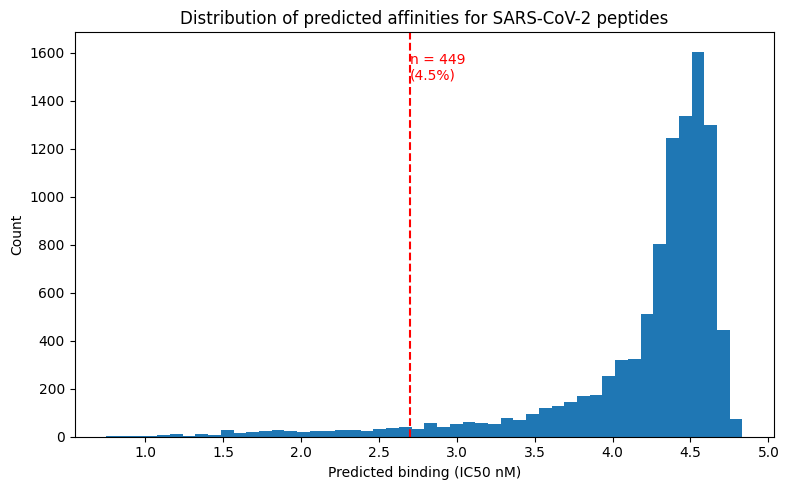

In [29]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(results['prediction'], bins=50)
plt.xlabel('Predicted binding (IC50 nM)')
plt.ylabel('Count')
plt.title('Distribution of predicted affinities for SARS-CoV-2 peptides')
plt.tight_layout()

# Binding threshold following IEDB guidance and recent vaccine studies:
# - IEDB help: Selecting thresholds / cut-offs for MHC binding predictions
#   https://help.iedb.org/hc/en-us/articles/114094151811-Selecting-thresholds-cut-offs-for-MHC-class-I-and-II-binding-predictions
# - Neoantigen / vaccine trials using similar affinity-based cutoffs (IC50 ≲ 500 nM, top ~1% binders):
#   https://www.nature.com/articles/s41586-023-06063-y      # Nature
#   https://www.nature.com/articles/s41591-024-02894-y      # Nat Med
#   https://www.nature.com/articles/s43018-025-00966-7      # Nat Cancer

# If predictions are log10(IC50), use:
threshold = np.log10(500)

# If predictions are raw IC50 in nM, use instead:
# threshold = 500

plt.axvline(x=threshold, color='r', linestyle='--')

# Count of peptides under the line (strong binders under IC50 < 500 nM)
mask = results['prediction'] < threshold
num_under = mask.sum()
prop_under = num_under / len(results)

print(f"Peptides with predicted IC50 below threshold: {num_under} ({prop_under:.2%})")

# Optional: annotate the plot with the count / proportion
ymin, ymax = plt.ylim()
plt.text(threshold, 0.95 * ymax,
         f"n = {num_under}\n({prop_under:.1%})",
         color='r', ha='left', va='top')

plt.show()

# Notes:
# - Here we adopt a binding threshold of IC50 < 500 nM and, conceptually,
#   a top ~1% rank criterion, following IEDB and the vaccine trials above.
# - The histogram + vertical line make the full distribution of predicted
#   pMHC affinities explicit, not just the top-ranked binders.


### 4.3 Visualize Embeddings (Optional)

If embeddings are saved in a compatible format, we can visualize them using dimensionality reduction (e.g., UMAP) and color points by predicted affinity. This helps identify clusters of strong vs. weak binders in the latent space.


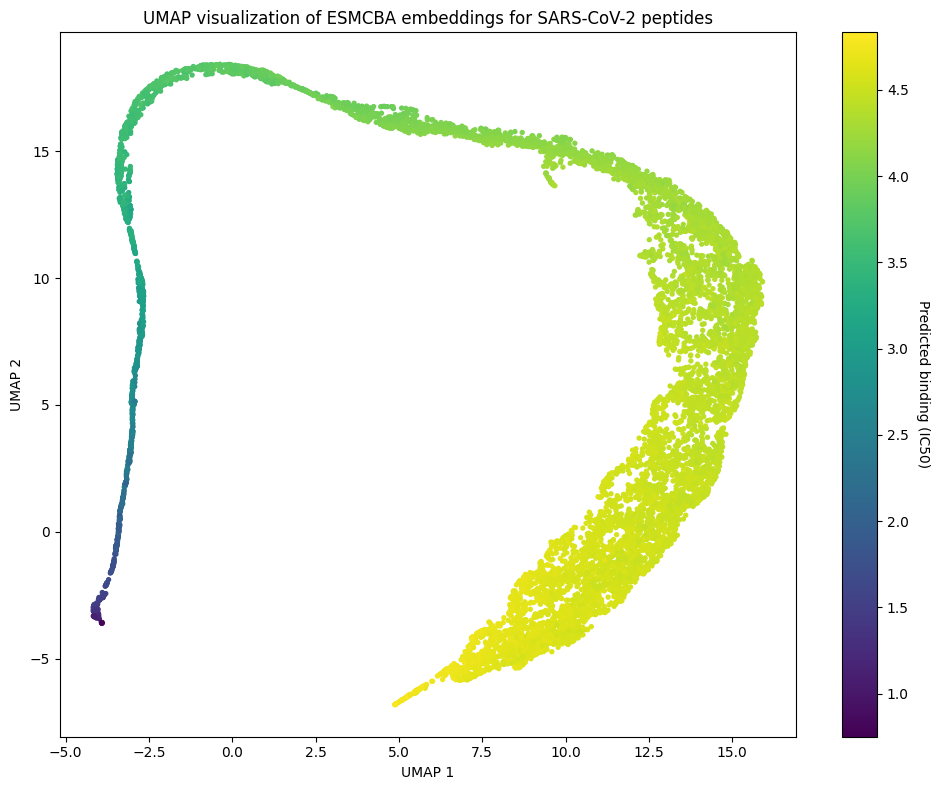

In [24]:
import matplotlib.pyplot as plt

# UMAP visualization of embeddings colored by predicted binding
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    results['UMAP_1'],
    results['UMAP_2'],
    c=results['prediction'],
    s=8
)

cbar = plt.colorbar(scatter)
cbar.set_label('Predicted binding (IC50)', rotation=270, labelpad=15)

plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP visualization of ESMCBA embeddings for SARS-CoV-2 peptides')
plt.tight_layout()
plt.show()


In [25]:
# 4.4 Summary statistics for predicted binding scores

summary = results['prediction'].describe(percentiles=[0.01, 0.05, 0.1, 0.5, 0.9, 0.95, 0.99])
summary

,prediction
count,10000.000000
mean,4.201418
std,0.613410
min,0.750951
1%,1.671115
5%,2.814878
10%,3.482208
50%,4.410655
90%,4.634432
95%,4.671033


---

## 📚 Section 5: Additional Resources and Next Steps

### 5.1 Available Scripts in ESMCBA Repository

1. **`embeddings_generation.py`** - Generate embeddings (covered in this notebook)
2. **`train_binding_affinity.py`** - Fine-tune models for binding affinity prediction
3. **`evaluate_model.py`** - Evaluate model performance on test sets
4. **`compare_predictors.py`** - Compare against external tools (MHCFlurry, HLAthena, etc.)
5. **`visualize_embeddings.py`** - Create UMAP visualizations
6. **`analyze_rfdiffusion.py`** - Analyze RFdiffusion pMHC designs

### 5.2 Model Checkpoints on Hugging Face

Explore other pre-trained models at [huggingface.co/smares/ESMCBA](https://huggingface.co/smares/ESMCBA):
- Models for different HLA alleles
- Different training configurations
- Epitope-only vs. epitope+HLA models

### 5.3 Citation

If you use ESMCBA in your research, please cite:

```
@article{mares2024esmcba,
  title={Continued domain-specific pre-training of protein language models for pMHC-I binding prediction},
  author={Mares, Sergio E. and Weinberger, Ariel Espinoza and Ioannidis, Nilah M.},
  journal={Preprint},
  year={2024},
  month={July}
}
```

### 5.4 Further Reading

- **ESM Models**: [Evolutionary Scale Modeling](https://github.com/facebookresearch/esm)
- **pMHC Binding**: Understanding peptide-MHC-I interactions
- **IEDB Database**: [Immune Epitope Database](https://www.iedb.org/)
- **HLA Nomenclature**: [IPD-IMGT/HLA Database](https://www.ebi.ac.uk/ipd/imgt/hla/)

---

Alternatively, if you already have a `peptides.tsv` file (one peptide per line), you can run the embedding generation step like this:


In [18]:
# Alternative: use a generic peptides.tsv file (one peptide per line)
!python3 ./embeddings_generation.py \
  --model_path ../../models/ESMCBA_epitope_0.8_30_ESMMASK_epitope_FT_5_0.001_1e-06_AUG_6_HLAA0201_2_0.001_1e-06__2_A0201_Hubber_A0201_final.pth \
  --name A0201-ESMCBA \
  --hla A0201 \
  --encoding epitope \
  --output_dir ./outputs \
  --peptides $(tr '\n' ' ' < peptides.tsv)


/bin/bash: line 1: peptides.tsv: No such file or directory
2025-11-13 01:33:54.511279: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762997634.530841    3176 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762997634.536857    3176 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1762997634.551956    3176 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762997634.551981    3176 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762997634.55198